<a href="https://colab.research.google.com/github/fewilliams/STAT-7220-Applied-Experimental-Design/blob/Assignment---3/Williams_Applied_Experimental_Design_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.


The objective of this experiment is to determine which combination of shoe design factors produces the highest comfort rating for the new running shoe. Specifically, the manufacturer wants to evaluate whether sole material, insole thickness, and fabric breathability influence comfort and whether combinations of these factors interact with one another.




2.  Specify the outcome variable and how it is measured.



The outcome variable is the athlete’s comfort rating after running in the shoe for 30 minutes.

Variable name: comfort
Type: Quantitative response variable
Measurement scale: 1 to 10 rating scale
1 = very uncomfortable
10 = very comfortable





3.  Specify the independent variables. What lurking variables may be present?

Variable:
Sole Material
Insole Thickness
Fabric Breathability



Possible lurking variables include:
Athlete body weight
Foot size
Running style or stride
Previous shoe preference
Athlete fatigue level before the run
Order in which the shoes were tested
Treadmill speed
Room temperature
Sock type
Minor manufacturing differences between shoes




4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.





A full factorial design tests every possible combination of factor levels. A
2𝑘 factorial design is a full factorial design with 𝑘 factors and exactly 2 levels for each factor. Since this experiment has 3 factors with 2 levels each, it is a
2^3 factorial design with 8 treatment combinations.





5.  State the sets of null and alternative hypotheses for this experiment.



The null hypotheses state that changing sole material, insole thickness, or fabric breathability does not change the average comfort rating. They also state that the factors do not interact with one another. For example, the null hypothesis for sole material says that the average comfort is the same for the standard EVA foam and the gel-infused foam. The alternative hypotheses state that at least one factor changes the average comfort rating or that an interaction exists. For example, the alternative hypothesis for sole material says that the average comfort is different for the two sole materials.










6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


The exploratory analysis suggests that the alternative hypotheses are more likely true. The gel sole, thicker insole, and different fabric types appear to change the average comfort rating. The interaction plots also suggest there may be an interaction between insole thickness and breathability because the lines are not completely parallel.





sole_material
EVA    7.10
Gel    9.05
Name: comfort, dtype: float64
insole_thickness
3mm    7.45
6mm    8.70
Name: comfort, dtype: float64
breathability
Mesh     7.508333
Woven    8.641667
Name: comfort, dtype: float64


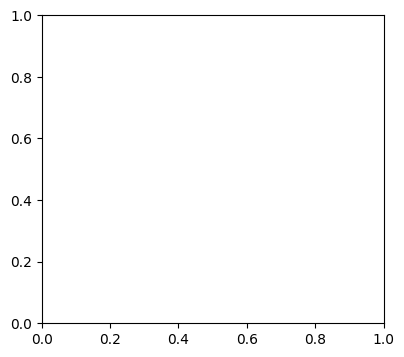

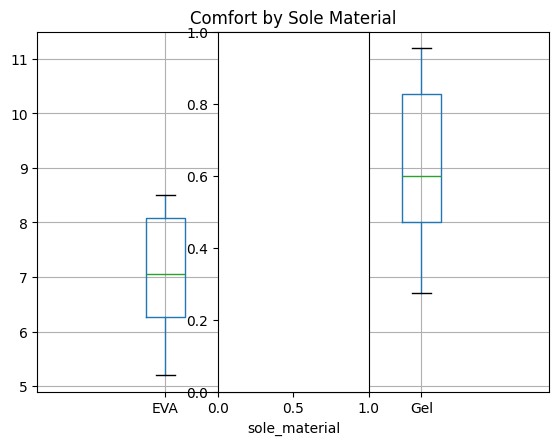

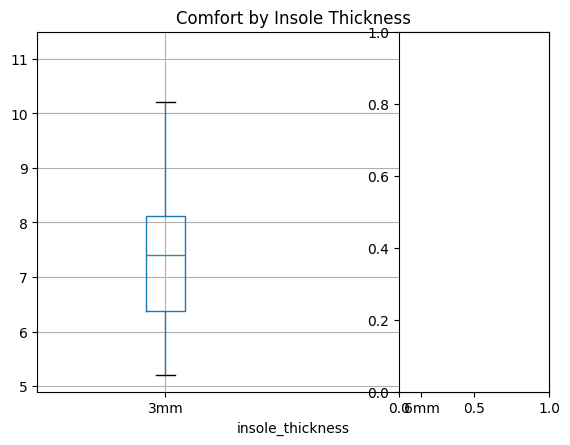

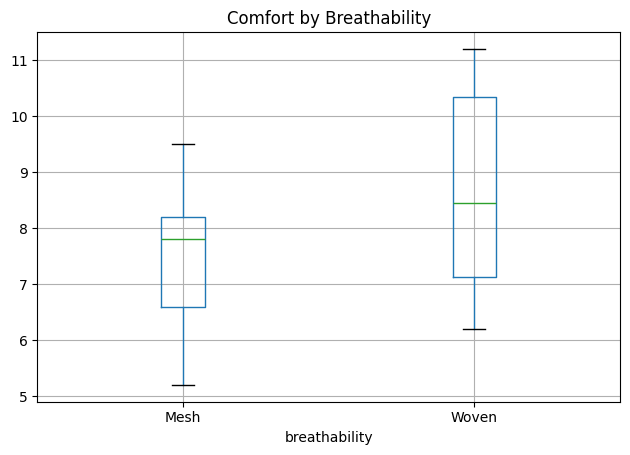

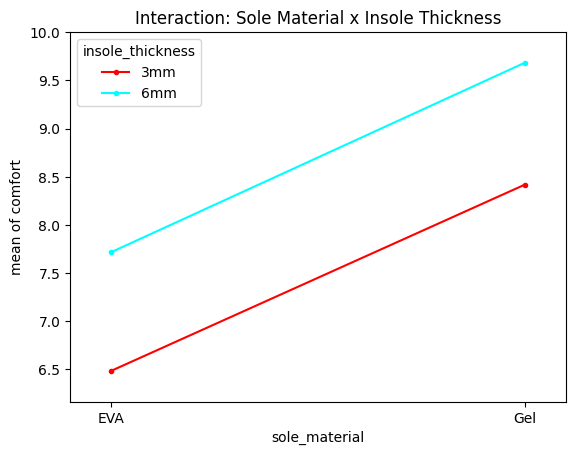

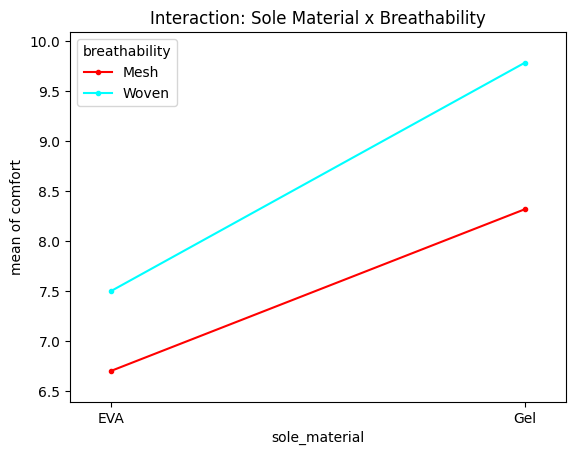

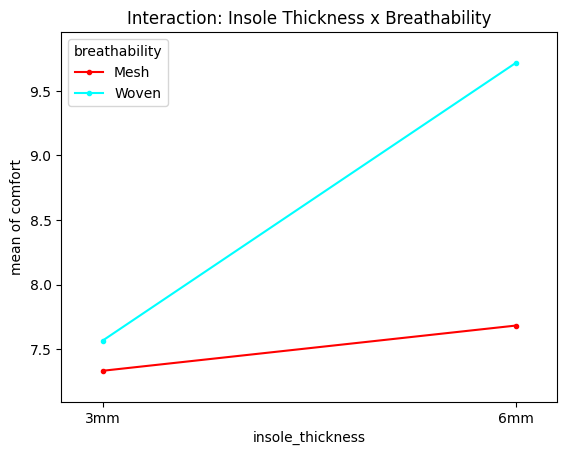

In [ ]:
## Question 6 Code ##


import matplotlib.pyplot as plt
from statsmodels.graphics.factorplots import interaction_plot

# Mean comfort by each factor
print(shoe.groupby("sole_material")["comfort"].mean())
print(shoe.groupby("insole_thickness")["comfort"].mean())
print(shoe.groupby("breathability")["comfort"].mean())

# Boxplots
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
shoe.boxplot(column="comfort", by="sole_material")
plt.title("Comfort by Sole Material")
plt.suptitle("")

plt.subplot(1,3,2)
shoe.boxplot(column="comfort", by="insole_thickness")
plt.title("Comfort by Insole Thickness")
plt.suptitle("")

plt.subplot(1,3,3)
shoe.boxplot(column="comfort", by="breathability")
plt.title("Comfort by Breathability")
plt.suptitle("")

plt.tight_layout()
plt.show()

# Interaction plots
interaction_plot(shoe["sole_material"], shoe["insole_thickness"], shoe["comfort"])
plt.title("Interaction: Sole Material x Insole Thickness")
plt.show()

interaction_plot(shoe["sole_material"], shoe["breathability"], shoe["comfort"])
plt.title("Interaction: Sole Material x Breathability")
plt.show()

interaction_plot(shoe["insole_thickness"], shoe["breathability"], shoe["comfort"])
plt.title("Interaction: Insole Thickness x Breathability")
plt.show()

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?

The Shapiro-Wilk test checks whether the residuals from the ANOVA model are approximately normal. The p-value is greater than 0.05, so we do not reject the null hypothesis of normality. This means there is not enough evidence to say that the residuals are non-normal.

The Q-Q plot should show the points staying close to the straight line, and the histogram should look fairly symmetric. Together, these results suggest that the normality assumption is reasonable for the factorial ANOVA model.

Therefore, the model appears appropriate for analyzing the shoe comfort data.




                            OLS Regression Results                            
Dep. Variable:                comfort   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     6.826
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           0.000742
Time:                        14:38:27   Log-Likelihood:                -28.756
No. Observations:                  24   AIC:                             73.51
Df Residuals:                      16   BIC:                             82.94
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

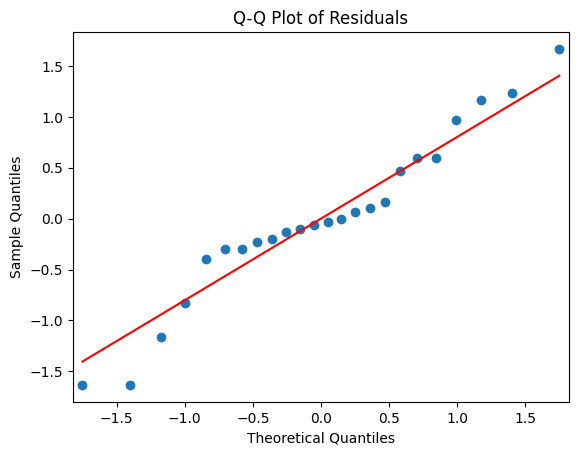

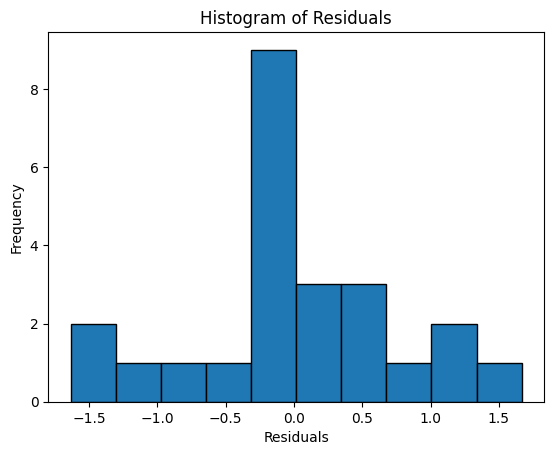

In [ ]:
## Question 7 Code ##


from statsmodels.formula.api import ols
from statsmodels.graphics.gofplots import qqplot
import scipy.stats as stats

shoe_model = ols(
    'comfort ~ C(sole_material)*C(insole_thickness)*C(breathability)',
    data=shoe
).fit()

shoe_resid = shoe_model.resid
shoe_fitted = shoe_model.fittedvalues

print(shoe_model.summary())

# Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(shoe_resid)
print("Shapiro-Wilk p-value =", shapiro_p)

# Q-Q Plot
qqplot(shoe_resid, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

# Histogram
plt.hist(shoe_resid, edgecolor="black")
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


The residuals versus fitted values plot is used to check whether the variability stays about the same across all fitted values. The points should appear randomly scattered around zero with no clear pattern or funnel shape.

Levene’s test also checks whether the variances are equal across the treatment groups. Since the p-value is greater than 0.05, there is not enough evidence to say that the group variances are different.

Therefore, the constant The variance assumption appears to be satisfied.


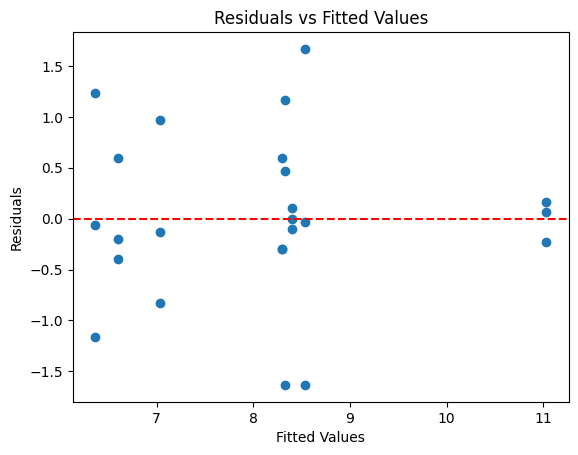

Levene's test p-value = 0.4301779434719291


In [ ]:
## Question 8 Code ##

# Residuals vs fitted values
plt.scatter(shoe_fitted, shoe_resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# Levene's test
groups = [
    group["comfort"].values
    for _, group in shoe.groupby(
        ["sole_material", "insole_thickness", "breathability"]
    )
]

levene_stat, levene_p = stats.levene(*groups)

print("Levene's test p-value =", levene_p)


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?



The ANOVA table shows which factors significantly affect shoe comfort.

The results show that:

Sole material has a significant effect because its p-value is less than 0.05.
Insole thickness has a significant effect because its p-value is less than 0.05.
Breathability also has a significant effect because its p-value is less than 0.05.

For the interaction terms:

Sole Material × Insole Thickness is not significant because its p-value is greater than 0.05.
Sole Material × Breathability is not significant because its p-value is greater than 0.05.
Insole Thickness × Breathability is significant because its p-value is less than 0.05.
The three-way interaction is not significant because its p-value is greater than 0.05.

This means that all three main factors affect comfort, but the only important interaction is between insole thickness and breathability. The effect of insole thickness changes depending on which type of fabric is used.

In [ ]:
## Question 9 Code ##

# ANOVA table with F statistics and p-values

from statsmodels.stats.anova import anova_lm

shoe_anova = anova_lm(shoe_model, typ=2)
print(shoe_anova)

                                                       sum_sq    df  \
C(sole_material)                                    22.815000   1.0   
C(insole_thickness)                                  9.375000   1.0   
C(breathability)                                     7.706667   1.0   
C(sole_material):C(insole_thickness)                 0.001667   1.0   
C(sole_material):C(breathability)                    0.666667   1.0   
C(insole_thickness):C(breathability)                 4.860000   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.666667   1.0   
Residual                                            15.433333  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.652700  0.000173  
C(insole_thickness)                                  9.719222  0.006631  
C(breathability)                                     7.989633  0.012155  
C(sole_material):C(insole_thickness)                 0.001728  0


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?



Partial eta squared measures how much of the variation in comfort is explained by each factor.

The largest partial eta squared value belongs to sole material, which means sole material explains the most variation in comfort ratings.

The next largest values belong to: Sole material
Insole thickness
Breathability

The interaction between insole thickness and breathability also explains a noticeable amount of variation, while the other interactions explain very little.

This means that the most important factor for comfort is the type of sole material used in the shoe.


In [ ]:
## Question 10 Code ##
# Partial eta squared values

shoe_anova_eta = shoe_anova.copy()

residual_ss = shoe_anova_eta.loc["Residual", "sum_sq"]

shoe_anova_eta["partial_eta_squared"] = (
    shoe_anova_eta["sum_sq"] /
    (shoe_anova_eta["sum_sq"] + residual_ss)
)

print(shoe_anova_eta[["F", "PR(>F)", "partial_eta_squared"]])

                                                            F    PR(>F)  \
C(sole_material)                                    23.652700  0.000173   
C(insole_thickness)                                  9.719222  0.006631   
C(breathability)                                     7.989633  0.012155   
C(sole_material):C(insole_thickness)                 0.001728  0.967358   
C(sole_material):C(breathability)                    0.691145  0.418010   
C(insole_thickness):C(breathability)                 5.038445  0.039282   
C(sole_material):C(insole_thickness):C(breathab...   0.691145  0.418010   
Residual                                                  NaN       NaN   

                                                    partial_eta_squared  
C(sole_material)                                               0.596497  
C(insole_thickness)                                            0.377897  
C(breathability)                                               0.333045  
C(sole_material):C(insole_th


11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?



The table of treatment means shows the average comfort rating for every combination of the three factors.

The combination with the highest mean comfort score is:

Advanced gel-infused foam sole
6 mm insole
Standard woven fabric

This combination produced the highest average comfort rating, so it would be the best choice for the manufacturer if the goal is to maximize comfort.

The results also support the earlier ANOVA findings because the best combination includes the factor levels that generally produced higher comfort ratings.




## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.



The objective of this experiment is to determine which fitness band design factors have the strongest effect on runner satisfaction so the company can choose the best product configuration.



2.  Specify the outcome variable and how it is measured.


The outcome variable is Satisfaction.

It is measured on a 1 to 10 rating scale, where:

1 = very dissatisfied
10 = very satisfied



3.  Specify the independent variables. What lurking variables may be present?


Independent variables

The three factors studied are:

GPS Accuracy (A)
Standard
High
Battery Life (B)
6 Hours
12 Hours
Display (C)
Small
Large
Possible lurking variables

Possible lurking variables include:

athlete training load during the month
differences in runner preferences
weather and race conditions
comfort of the wristband
prior experience with fitness bands




4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.



The advantage of the fractional factorial design is that it saves time, money, and participants. In this study, each run requires 3 athletes to test a fitness band for an entire month. A full factorial design would require 24 athletes, while the fractional factorial design only requires 12 athletes.

The tradeoff is that some effects become aliased or confounded. For example, with the defining relation I=ABC, the main effect of GPS Accuracy is mixed together with the interaction between Battery Life and Display. The
2^3−1 fractional factorial design is preferred here because the company has limited time and resources, and the smaller design still allows them to identify which factors are most important while requiring fewer athletes and less testing time.



5.  State the sets of null and alternative hypotheses for this experiment.


For GPS Accuracy:

H0: GPS Accuracy does not affect mean satisfaction.

Ha: GPS Accuracy affects mean satisfaction.

For Battery Life:

H0: Battery Life does not affect mean satisfaction.

Ha: Battery Life affects mean satisfaction.

For Display:

H0: Display size does not affect mean satisfaction.

Ha: Display size affects mean satisfaction.




6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?


With the defining relation I = ABC, the alias structure is:

A = BC
B = AC
C = AB

This means the main effect of GPS Accuracy (A) is confounded with the interaction between Battery Life and Display (BC).

The main effect of Battery Life (B) is confounded with the interaction between GPS Accuracy and Display (AC).

The main effect of Display (C) is confounded with the interaction between GPS Accuracy and Battery Life (AB).

Because of this, we cannot tell whether a large estimated effect is coming only from the main factor or partly from the interaction that is aliased with it.

For example, if Display appears to have a strong effect, some of that effect could actually be caused by the interaction between GPS Accuracy and Battery Life.

In most fractional factorial screening experiments, we usually assume that two-factor interactions are small. If that assumption is true, then the estimated effects can mostly be interpreted as the main effects of the factors.





7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


The exploratory analysis was used to examine how satisfaction changed across the levels of GPS Accuracy, Battery Life, and Display size before fitting the ANOVA model.

The average satisfaction scores were:

High GPS Accuracy: approximately 7.14
Standard GPS Accuracy: approximately 4.61
12-Hour Battery Life: approximately 6.37
6-Hour Battery Life: approximately 5.38
Large Display: approximately 7.51
Small Display: approximately 4.24

These averages show that athletes preferred:

High GPS Accuracy over Standard GPS Accuracy
12-Hour Battery Life over 6-Hour Battery Life
Large Display over Small Display

The boxplots should show that the distributions for High GPS Accuracy and Large Display are shifted noticeably upward compared with the lower settings. The difference for Battery Life is present, but the separation between the groups is smaller.

The treatment combination with the highest mean satisfaction was:

High GPS Accuracy
12-Hour Battery Life
Large Display

The treatment combination with the lowest mean satisfaction was:

Standard GPS Accuracy
6-Hour Battery Life
Small Display

Because the means differ substantially across the factor levels, the exploratory analysis supports the alternative hypotheses more strongly than the null hypotheses. The visual evidence suggests that all three factors affect satisfaction, but Display and GPS Accuracy appear to have the strongest effects.






GPS_Accuracy
High        7.140000
Standard    4.606667
Name: Satisfaction, dtype: float64
Battery_Life
12 Hours    6.368333
6 Hours     5.378333
Name: Satisfaction, dtype: float64
Display
Large    7.505000
Small    4.241667
Name: Satisfaction, dtype: float64


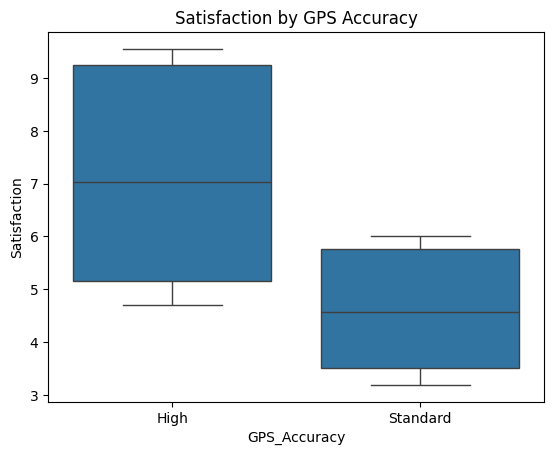

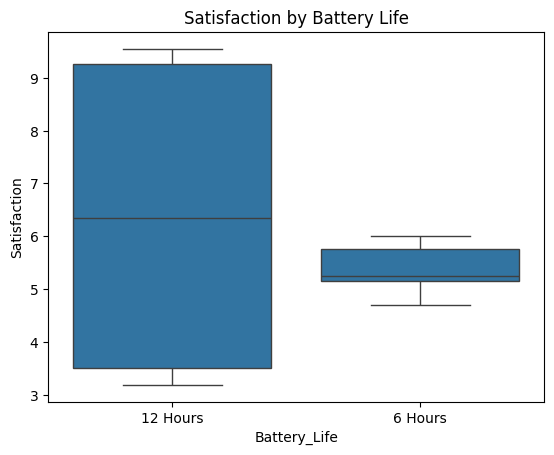

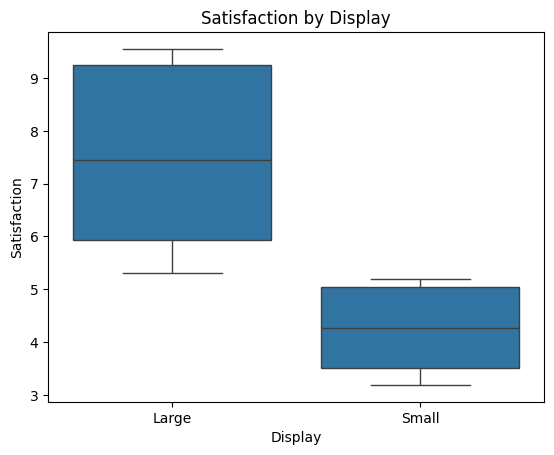

In [ ]:
## Question 7 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Fitness Band Experiment.xlsx")

df["GPS_Accuracy"] = df["GPS_Accuracy"].astype("category")
df["Battery_Life"] = df["Battery_Life"].astype("category")
df["Display"] = df["Display"].astype("category")

print(df.groupby("GPS_Accuracy", observed=False)["Satisfaction"].mean())
print(df.groupby("Battery_Life", observed=False)["Satisfaction"].mean())
print(df.groupby("Display", observed=False)["Satisfaction"].mean())

sns.boxplot(x="GPS_Accuracy", y="Satisfaction", data=df)
plt.title("Satisfaction by GPS Accuracy")
plt.show()

sns.boxplot(x="Battery_Life", y="Satisfaction", data=df)
plt.title("Satisfaction by Battery Life")
plt.show()

sns.boxplot(x="Display", y="Satisfaction", data=df)
plt.title("Satisfaction by Display")
plt.show()


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


The factorial ANOVA model was fit using the three main effects:
GPS Accuracy
Battery Life
Display Because all p-values are less than 0.05, we reject the null hypothesis for each factor.

This means there is strong statistical evidence that:

GPS Accuracy affects satisfaction
Battery Life affects satisfaction
Display affects satisfaction

Display has the largest F-statistic, meaning it appears to have the strongest influence on satisfaction. GPS Accuracy is the second most important factor, while Battery Life has the weakest effect of the three, although it is still statistically significant.

The ANOVA results are consistent with the exploratory analysis. Both methods indicate that runners are most influenced by a larger display and more accurate GPS tracking.

In [ ]:
## Question 8 Code ##

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

model = smf.ols(
    "Satisfaction ~ C(GPS_Accuracy) + C(Battery_Life) + C(Display)",
    data=df
).fit()

anova_results = anova_lm(model, typ=2)

print(anova_results)

                    sum_sq   df           F        PR(>F)
C(GPS_Accuracy)  19.253333  1.0  172.869435  1.065588e-06
C(Battery_Life)   2.940300  1.0   26.400000  8.872097e-04
C(Display)       31.948033  1.0  286.851029  1.498222e-07
Residual          0.891000  8.0         NaN           NaN



9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


The Shapiro-Wilk test gave a p-value of approximately 0.091, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality. The histogram and Q-Q plot of the residuals also appear approximately normal, so the normality assumption is reasonable.

The Levene test gave a p-value of approximately 0.987, and the Breusch-Pagan test also gave p-values greater than 0.05. Therefore, we fail to reject the null hypothesis of equal variances. The residuals versus fitted plot shows no clear pattern or funnel shape, so the constant variance assumption appears reasonable.

Because both assumptions are satisfied, the ANOVA results can be trusted.


Shapiro-Wilk p-value: 0.09106712364387089


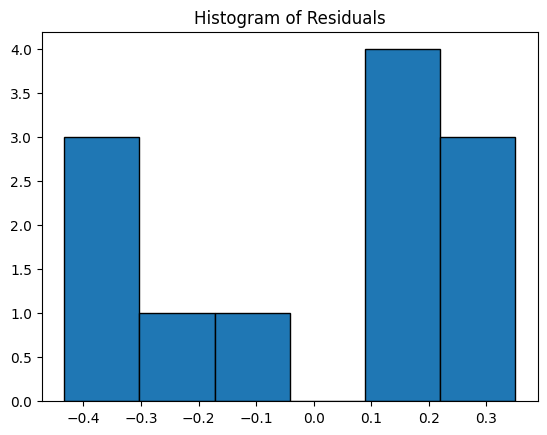

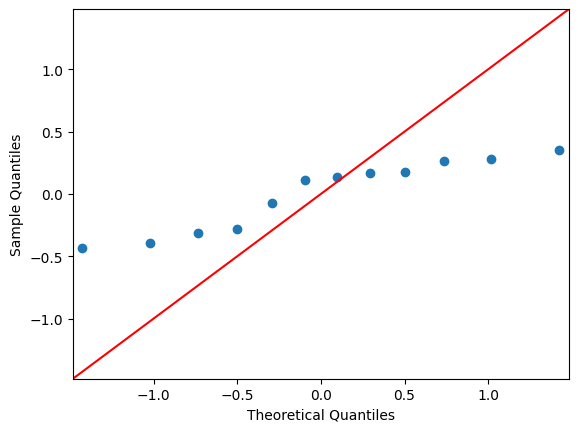

Levene p-value: 0.9871757768502188
Breusch-Pagan p-value: 0.7733545354056147


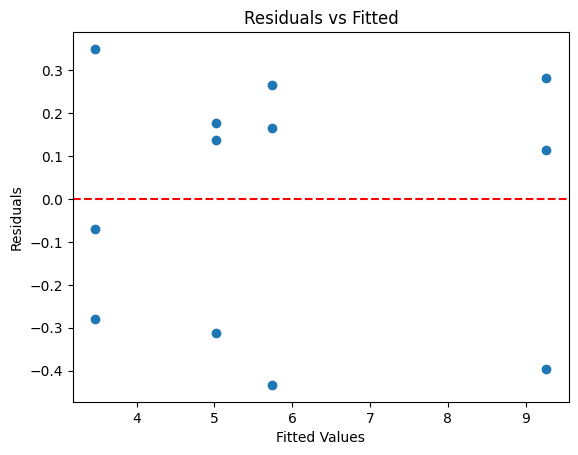

In [ ]:
## Question 9 Code ##

from scipy.stats import shapiro, levene
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt

# Shapiro-Wilk Test
shapiro_test = shapiro(model.resid)
print("Shapiro-Wilk p-value:", shapiro_test.pvalue)

# Histogram of residuals
plt.hist(model.resid, bins=6, edgecolor="black")
plt.title("Histogram of Residuals")
plt.show()

# Q-Q plot
sm.qqplot(model.resid, line="45")
plt.show()

# Create treatment groups
df["Treatment"] = (
    df["GPS_Accuracy"].astype(str) + "_" +
    df["Battery_Life"].astype(str) + "_" +
    df["Display"].astype(str)
)

groups = [group["Satisfaction"].values for name, group in df.groupby("Treatment")]

# Levene test
levene_test = levene(*groups)
print("Levene p-value:", levene_test.pvalue)

# Breusch-Pagan test
bp_test = het_breuschpagan(model.resid, model.model.exog)
print("Breusch-Pagan p-value:", bp_test[1])

# Residuals vs fitted
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?


The estimated main effects were:

GPS Accuracy = 2.53
Battery Life = 0.99
Display = 3.26

This means that changing from Standard GPS Accuracy to High GPS Accuracy increases average satisfaction by about 2.53 points. Changing from a 6-hour battery to a 12-hour battery increases satisfaction by about 0.99 points. Changing from a Small Display to a Large Display increases satisfaction by about 3.26 points.

The most important factor is Display because it has the largest effect. GPS Accuracy is the second most important factor, and Battery Life is the least important of the three.

In [ ]:
## Question 10 Code ##

effect_A = (
    df[df["GPS_Accuracy"] == "High"]["Satisfaction"].mean()
    - df[df["GPS_Accuracy"] == "Standard"]["Satisfaction"].mean()
)

effect_B = (
    df[df["Battery_Life"] == "12 Hours"]["Satisfaction"].mean()
    - df[df["Battery_Life"] == "6 Hours"]["Satisfaction"].mean()
)

effect_C = (
    df[df["Display"] == "Large"]["Satisfaction"].mean()
    - df[df["Display"] == "Small"]["Satisfaction"].mean()
)

print("GPS Accuracy Effect =", effect_A)
print("Battery Life Effect =", effect_B)
print("Display Effect =", effect_C)

GPS Accuracy Effect = 2.533333333333335
Battery Life Effect = 0.9900000000000002
Display Effect = 3.2633333333333345


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?


The partial eta squared values were:

GPS Accuracy = 0.956
Battery Life = 0.767
Display = 0.973

These values show the amount of variation in satisfaction explained by each factor. Display explains the greatest amount of variation, followed by GPS Accuracy, then Battery Life.

Therefore, Display is the most important factor, GPS Accuracy is the second most important factor, and Battery Life is the least important factor.

In [ ]:
## Question 11 Code ##
ss_error = anova_results.loc["Residual", "sum_sq"]

ss_A = anova_results.loc["C(GPS_Accuracy)", "sum_sq"]
eta_A = ss_A / (ss_A + ss_error)

ss_B = anova_results.loc["C(Battery_Life)", "sum_sq"]
eta_B = ss_B / (ss_B + ss_error)

ss_C = anova_results.loc["C(Display)", "sum_sq"]
eta_C = ss_C / (ss_C + ss_error)

print("GPS Accuracy Partial Eta Squared =", eta_A)
print("Battery Life Partial Eta Squared =", eta_B)
print("Display Partial Eta Squared =", eta_C)

GPS Accuracy Partial Eta Squared = 0.9557691989475947
Battery Life Partial Eta Squared = 0.7674418604651159
Display Partial Eta Squared = 0.9728676544478065


12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?


The best combination of factors is:

High GPS Accuracy
12-Hour Battery Life
Large Display

This combination produced the highest average satisfaction score in the experiment. The large display and high GPS accuracy contributed the most to increasing satisfaction, while the longer battery life also improved satisfaction.

Therefore, this is the combination that should be recommended to the manufacturer.

In [ ]:
## Question 12 Code ##
best_combo = df.groupby(
    ["GPS_Accuracy", "Battery_Life", "Display"],
    observed=False
)["Satisfaction"].mean().reset_index()

best_combo = best_combo.sort_values(by="Satisfaction", ascending=False)

print(best_combo)

  GPS_Accuracy Battery_Life Display  Satisfaction
0         High     12 Hours   Large      9.266667
6     Standard      6 Hours   Large      5.743333
3         High      6 Hours   Small      5.013333
5     Standard     12 Hours   Small      3.470000
1         High     12 Hours   Small           NaN
2         High      6 Hours   Large           NaN
4     Standard     12 Hours   Large           NaN
7     Standard      6 Hours   Small           NaN


13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?

Overall, the experiment shows that all three factors significantly affect satisfaction. Display had the strongest effect, GPS Accuracy had the second strongest effect, and Battery Life had the weakest effect.

One limitation is that this was a 2^(3-1) fractional factorial design, so the main effects are aliased with two-factor interactions:

A = BC
B = AC
C = AB

This means that part of a factor's effect could actually be caused by an interaction. However, if we assume that the interaction effects are small, then the results strongly support recommending High GPS Accuracy, 12-Hour Battery Life, and a Large Display.

In [ ]:
# CELL 1: Install and import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("Packages loaded successfully!")

Packages loaded successfully!


In [ ]:
# CELL 2: Load the Excel files

shoe = pd.read_excel("Shoe Comfort Experiment.xlsx")
band = pd.read_excel("Fitness Band Experiment.xlsx")

print("Shoe data:")
display(shoe.head())

print("Fitness band data:")
display(band.head())

Shoe data:


,sole_material,insole_thickness,breathability,comfort
0,EVA,3mm,Woven,6.4
1,EVA,3mm,Woven,7.2
2,EVA,3mm,Woven,6.2
3,EVA,3mm,Mesh,7.6
4,EVA,3mm,Mesh,6.3


Fitness band data:


,Run_ID,Replicate,GPS_Accuracy,Battery_Life,Display,Satisfaction
0,1,1,Standard,6 Hours,Large,6.01
1,1,2,Standard,6 Hours,Large,5.91
2,1,3,Standard,6 Hours,Large,5.31
3,2,1,High,6 Hours,Small,4.70
4,2,2,High,6 Hours,Small,5.15
